In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [5]:
df = pd.read_csv("/kaggle/input/california-housing-prices/housing.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/california-housing-prices/housing.csv'

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df['total_bedrooms'].fillna(df['total_bedrooms'].mean(),inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [10]:
mapping = {'<1H OCEAN': 1,'INLAND': 2,'NEAR OCEAN': 3,'NEAR BAY':4,'ISLAND':5}
df['ocean_proximity'] = df['ocean_proximity'].map(mapping)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'ocean_proximity'}>, <Axes: >, <Axes: >]],
      dtype=object)

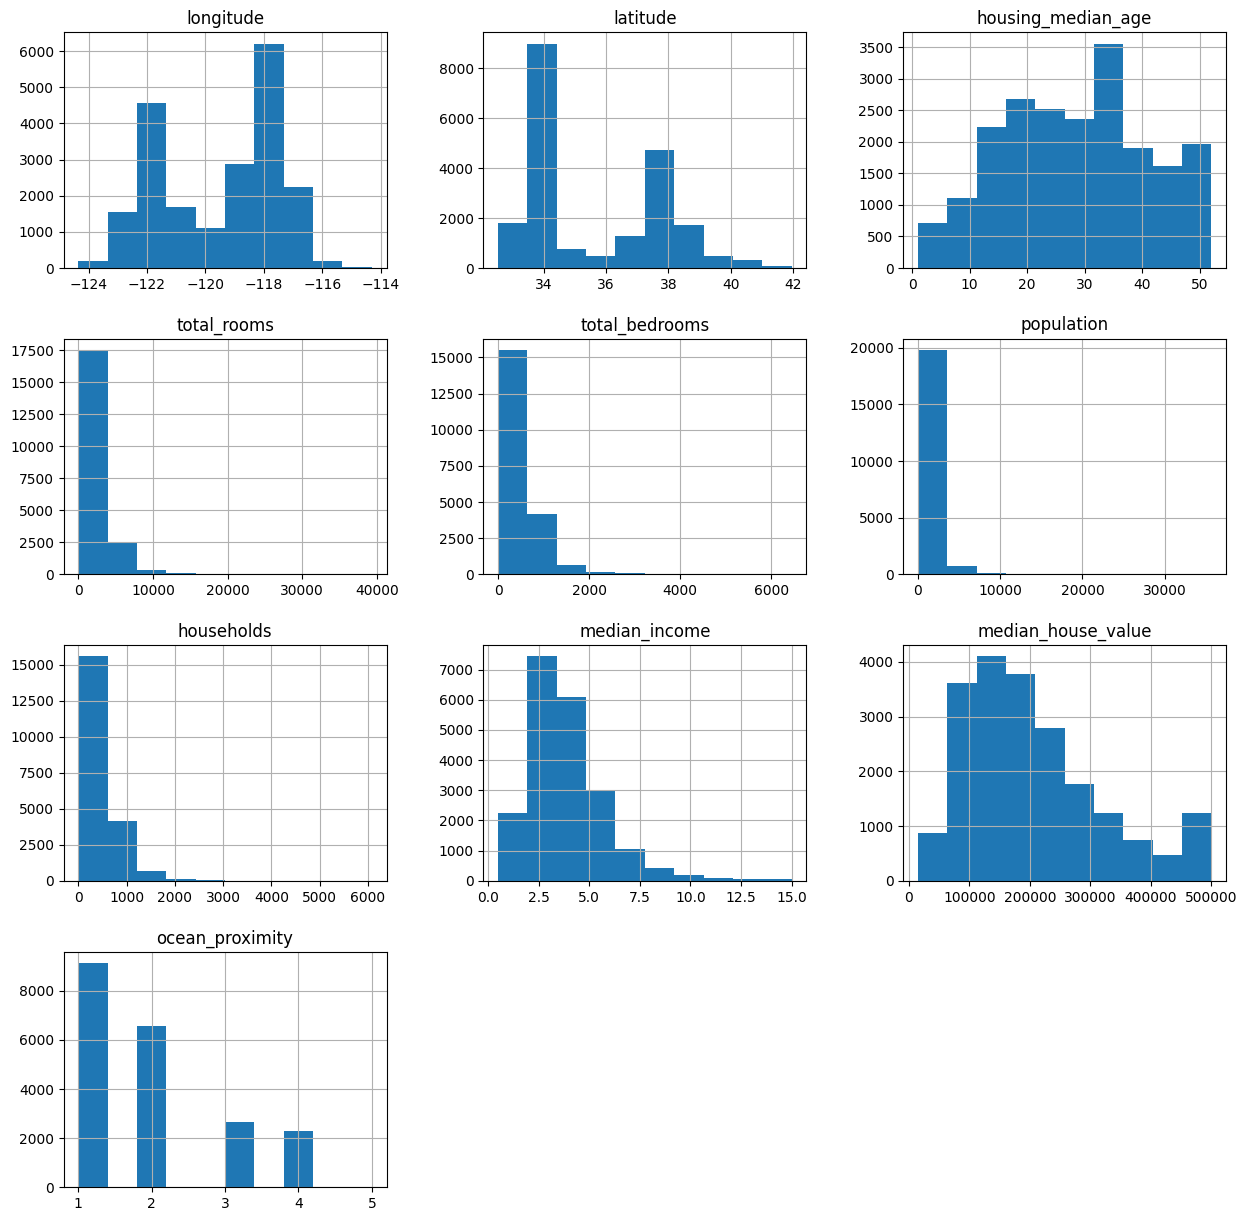

In [11]:
df.hist(figsize=(15, 15))

<Axes: >

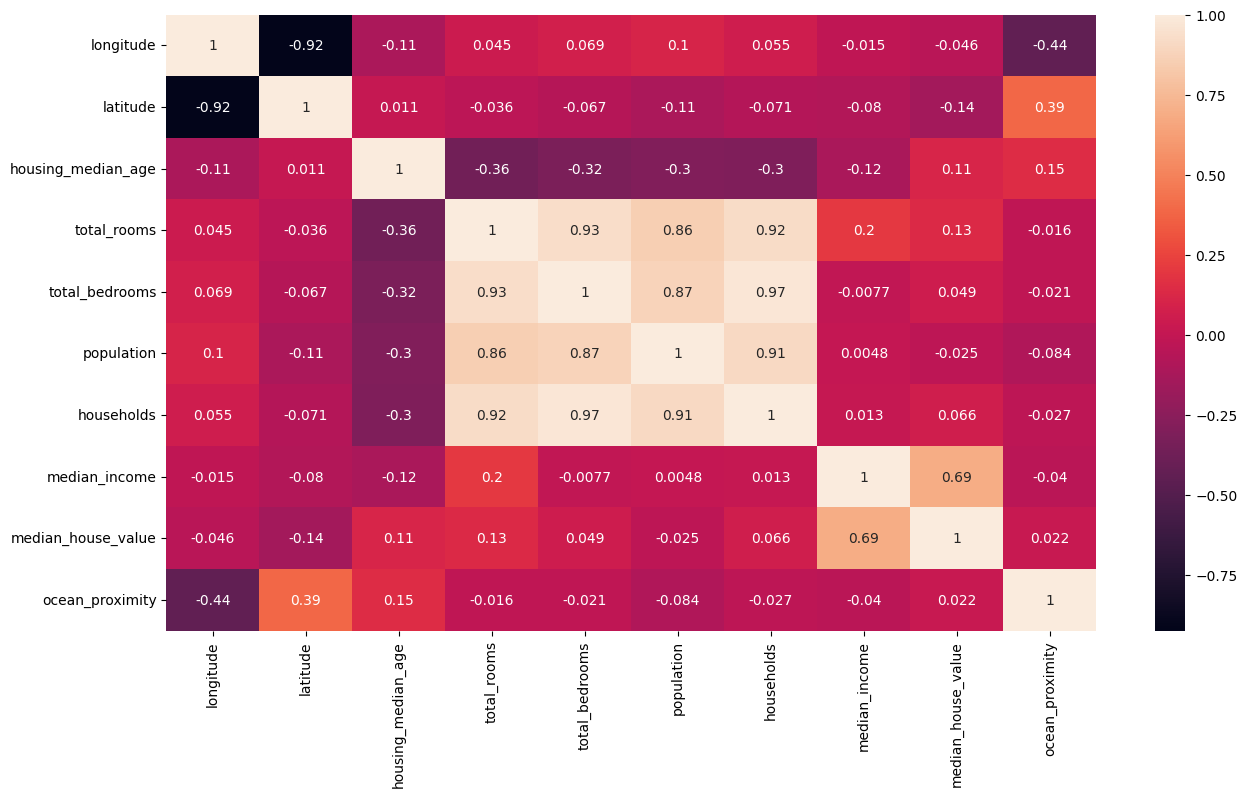

In [12]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True)

In [13]:
X = df.drop(['median_house_value'],axis=1)
y = df['median_house_value']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [14]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [15]:
y_pred = reg.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test,y_pred))
print('Training Score: ', reg.score(X_train, y_train))
print('Testing Score: ', reg.score(X_test, y_test))
print('RMSE: ',rmse)

Training Score:  0.6373833667145292
Testing Score:  0.6281544403553274
RMSE:  69838.84419182673


<Figure size 1200x800 with 0 Axes>

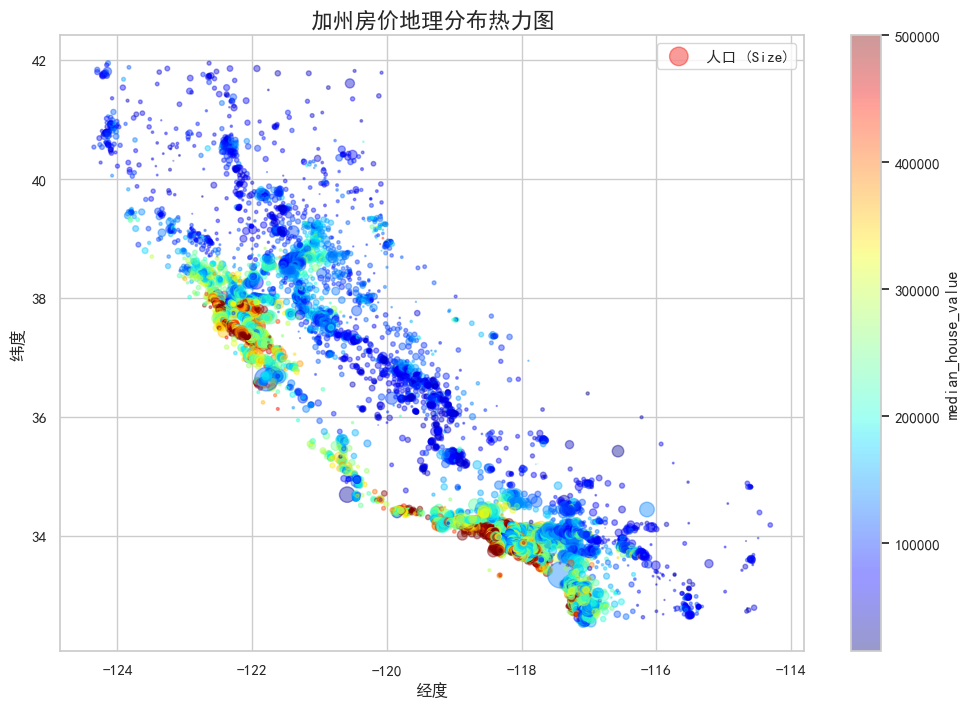

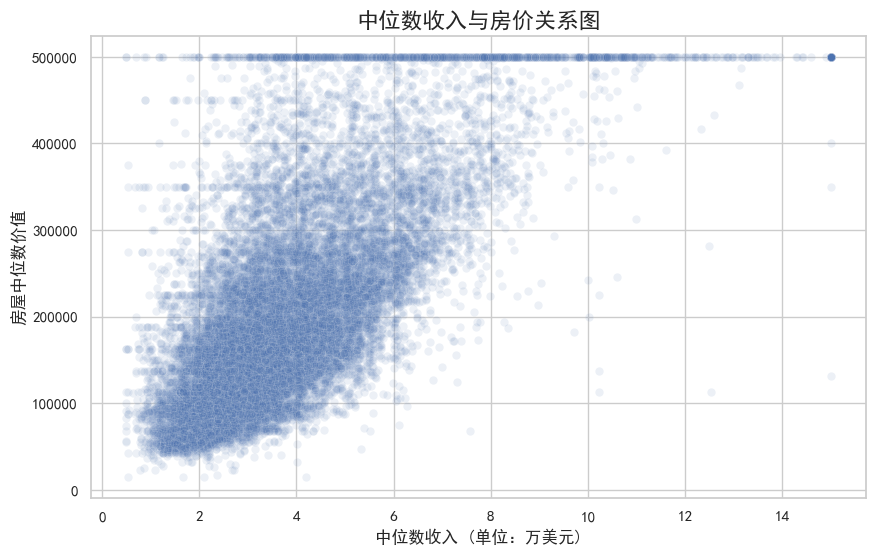

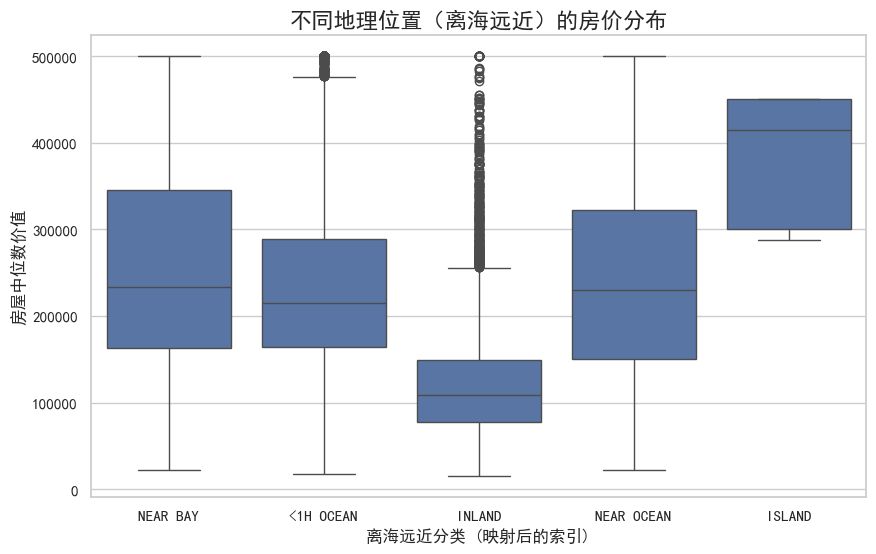

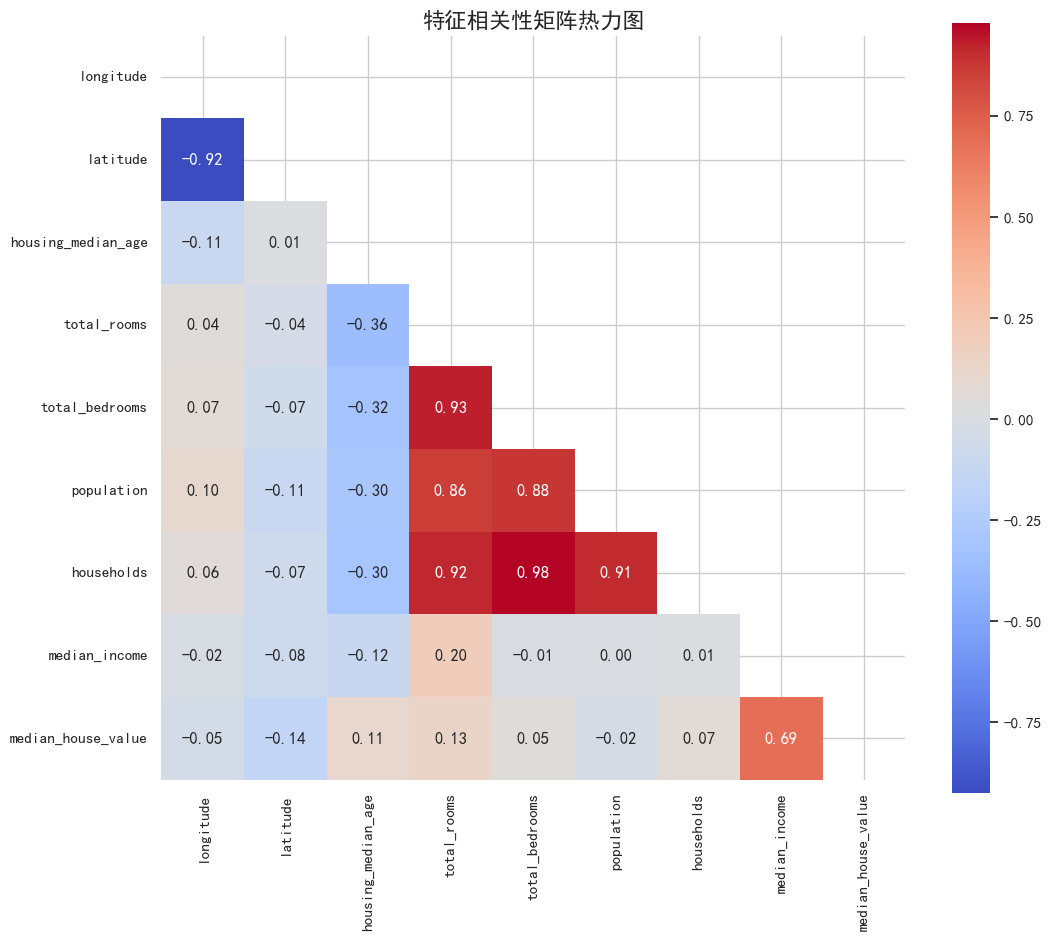

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False 

# --- 可视化 1：地理散点图（任务书要求的“分布图”进阶版） ---
# 结合经纬度、人口和房价，直观展示加州房价的地理分布规律
plt.figure(figsize=(12,8))
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=df["population"]/100, label="人口 (Size)", figsize=(12, 8),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
    sharex=False)
plt.title("加州房价地理分布热力图", fontsize=16)
plt.xlabel("经度", fontsize=12)
plt.ylabel("纬度", fontsize=12)
plt.legend()
plt.show()
# 意义：展示了靠海地区及大城市周边房价明显更高。

# --- 可视化 2：中位数收入与房价的散点图 ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="median_income", y="median_house_value", alpha=0.1)
plt.title("中位数收入与房价关系图", fontsize=16)
plt.xlabel("中位数收入 (单位：万美元)", fontsize=12)
plt.ylabel("房屋中位数价值", fontsize=12)
plt.show()
# 意义：展示了明显的线性相关性，同时也暴露出 500,000 元处的封顶异常值。

# --- 可视化 3：离海远近与房价的箱线图（分类变量分析） ---
plt.figure(figsize=(10, 6))
# 注意：如果你之前已经将 ocean_proximity 映射为数字，这里可以使用映射后的值或原始值
sns.boxplot(x="ocean_proximity", y="median_house_value", data=df)
plt.title("不同地理位置（离海远近）的房价分布", fontsize=16)
plt.xlabel("离海远近分类 (映射后的索引)", fontsize=12)
plt.ylabel("房屋中位数价值", fontsize=12)
plt.show()
# 意义：分析不同区域（如岛屿、内陆、近海）对价格的影响。

# --- 可视化 4：特征相关性热力图（保留并优化） ---
# 只对数值列计算相关性，避免非数值列导致错误
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool)) # 只显示上三角/下三角以便阅读
sns.heatmap(num_df.corr(), mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("特征相关性矩阵热力图", fontsize=16)
plt.show()

In [6]:
# 从工作区加载本地数据并做简单预处理
import os
csv_path = os.path.join('..','..','data','raw','housing.csv')
print('加载数据路径:', csv_path)
df = pd.read_csv(csv_path)
# 缺失值填充
if 'total_bedrooms' in df.columns:
    df['total_bedrooms'].fillna(df['total_bedrooms'].mean(), inplace=True)
# ocean_proximity 映射为数值（若为字符串）
if 'ocean_proximity' in df.columns and df['ocean_proximity'].dtype == object:
    mapping = {'<1H OCEAN': 1,'INLAND': 2,'NEAR OCEAN': 3,'NEAR BAY':4,'ISLAND':5}
    df['ocean_proximity'] = df['ocean_proximity'].map(mapping)

# 显示前几行以确认
print(df.shape)
df.head()

加载数据路径: ..\..\data\raw\housing.csv
(20640, 10)


C:\Users\hjr\AppData\Local\Temp\ipykernel_24200\782998203.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['total_bedrooms'].fillna(df['total_bedrooms'].mean(), inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
